# 1BM110 - Assignment 1 - Group 7

**Students & IDs** \
Kazimir Breuer - 1574639 \
Daphne Gomes de Mesquita - 1678507 \
Isabelle Weenink - 1722239  \
Renske Quekel - ??

**Date** \
10th of March 2026

## Import Libraries


In [1882]:
# Import libraries
import pandas as pd
import numpy as np  
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

---

# 1. Load the Dataset (3 pts)

## 1.1 Load Data



In [1883]:
# Load datasets
df   = pd.read_csv('energy_generation_train.csv')  # train set
test = pd.read_csv('energy_generation_test.csv')   # test set



In [1884]:
print("Train set:")
display(df.head())

print("Test set:")
display(test.head())


Train set:


,DateTime,Biomass,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Hydro Run-of-river and poundage,Hydro Water Reservoir,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore
0,2023-01-01 00:00:00,0.0,NaN,NaN,919.0,1225.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,161.0,NaN,1.0,69.0,1893.0,807.0
1,2023-01-01 00:15:00,0.0,NaN,NaN,921.0,1235.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,139.0,NaN,1.0,70.0,1367.0,741.0
2,2023-01-01 00:30:00,0.0,NaN,NaN,922.0,1249.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,139.0,NaN,1.0,69.0,1052.0,686.0
3,2023-01-01 00:45:00,0.0,NaN,NaN,966.0,1254.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,140.0,NaN,1.0,68.0,1090.0,682.0
4,2023-01-01 01:00:00,0.0,NaN,NaN,999.0,1258.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,137.0,NaN,1.0,68.0,1082.0,760.0


Test set:


,DateTime,Biomass,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Hydro Run-of-river and poundage,Hydro Water Reservoir,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore
0,2024-02-01 00:00:00,0.0,NaN,NaN,1795.0,950.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,185.0,NaN,0.0,69.0,3260.0,1207.0
1,2024-02-01 00:15:00,0.0,NaN,NaN,1586.0,958.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,206.0,NaN,0.0,70.0,3269.0,1199.0
2,2024-02-01 00:30:00,0.0,NaN,NaN,1349.0,1055.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,208.0,NaN,0.0,69.0,3272.0,1180.0
3,2024-02-01 00:45:00,0.0,NaN,NaN,1264.0,997.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,184.0,NaN,0.0,64.0,3275.0,1180.0
4,2024-02-01 01:00:00,0.0,NaN,NaN,1278.0,982.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,184.0,NaN,0.0,61.0,3277.0,1183.0


## 1.2 Ensure Correct Data Types

Convert columns to appropriate data types:
- **float/int** for numeric quantities
- **object** for categorical variables
- **datetime** for dates

In [1885]:
# Show datatypes for both sets
print("Train set:")
display(pd.DataFrame({'Data Type': df.dtypes}))

print("Test set:")
display(pd.DataFrame({'Data Type': test.dtypes}))


Train set:


,Data Type
DateTime,str
Biomass,float64
Fossil Brown coal/Lignite,float64
Fossil Coal-derived gas,float64
Fossil Gas,float64
Fossil Hard coal,float64
Fossil Oil,float64
Fossil Oil shale,float64
Fossil Peat,float64
Geothermal,float64


Test set:


,Data Type
DateTime,str
Biomass,float64
Fossil Brown coal/Lignite,float64
Fossil Coal-derived gas,float64
Fossil Gas,float64
Fossil Hard coal,float64
Fossil Oil,float64
Fossil Oil shale,float64
Fossil Peat,float64
Geothermal,float64


In [1886]:
# Ensure all columns have the correct data type for both sets
for dataset in [df, test]:
    dataset['DateTime'] = pd.to_datetime(dataset['DateTime'])
    numeric_cols = dataset.columns.drop('DateTime')
    dataset[numeric_cols] = dataset[numeric_cols].apply(pd.to_numeric, errors='coerce')


In [1887]:
# Verify data types are correct now
print("Train set:")
display(pd.DataFrame({'Data Type': df.dtypes}))

print("Test set:")
display(pd.DataFrame({'Data Type': test.dtypes}))


Train set:


,Data Type
DateTime,datetime64[us]
Biomass,float64
Fossil Brown coal/Lignite,float64
Fossil Coal-derived gas,float64
Fossil Gas,float64
Fossil Hard coal,float64
Fossil Oil,float64
Fossil Oil shale,float64
Fossil Peat,float64
Geothermal,float64


Test set:


,Data Type
DateTime,datetime64[us]
Biomass,float64
Fossil Brown coal/Lignite,float64
Fossil Coal-derived gas,float64
Fossil Gas,float64
Fossil Hard coal,float64
Fossil Oil,float64
Fossil Oil shale,float64
Fossil Peat,float64
Geothermal,float64


## 1.3 Data Inspection

Display the first few rows and basic information about the dataset.

In [1888]:
# Display basic statistics

print("\nRemaining columns:", df.columns.tolist())
df.head()



Remaining columns: ['DateTime', 'Biomass', 'Fossil Brown coal/Lignite', 'Fossil Coal-derived gas', 'Fossil Gas', 'Fossil Hard coal', 'Fossil Oil', 'Fossil Oil shale', 'Fossil Peat', 'Geothermal', 'Hydro Pumped Storage', 'Hydro Pumped Storage.1', 'Hydro Run-of-river and poundage', 'Hydro Water Reservoir', 'Marine', 'Nuclear', 'Other', 'Other renewable', 'Solar', 'Waste', 'Wind Offshore', 'Wind Onshore']


,DateTime,Biomass,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Hydro Run-of-river and poundage,Hydro Water Reservoir,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore
0,2023-01-01 00:00:00,0.0,NaN,NaN,919.0,1225.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,161.0,NaN,1.0,69.0,1893.0,807.0
1,2023-01-01 00:15:00,0.0,NaN,NaN,921.0,1235.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,139.0,NaN,1.0,70.0,1367.0,741.0
2,2023-01-01 00:30:00,0.0,NaN,NaN,922.0,1249.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,139.0,NaN,1.0,69.0,1052.0,686.0
3,2023-01-01 00:45:00,0.0,NaN,NaN,966.0,1254.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,140.0,NaN,1.0,68.0,1090.0,682.0
4,2023-01-01 01:00:00,0.0,NaN,NaN,999.0,1258.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,137.0,NaN,1.0,68.0,1082.0,760.0


## Insert timestamps for each timeframe

In [1889]:
# Check the timeframe and identify missing 15-min timestamps for both sets
# Collect missing timestamps for both sets first (shown as a summary table on top)
missing_summary = {}

for label, dataset in [("Train", df), ("Test", test)]:
    full_range = pd.date_range(start=dataset["DateTime"].min(),
                               end=dataset["DateTime"].max(), freq="15min")
    missing_times = full_range.difference(pd.to_datetime(dataset["DateTime"]))
    missing_summary[label] = missing_times

# Summary table on top
summary_df = pd.DataFrame({
    "Set":      ["Train", "Test"],
    "Timeframe start": [df["DateTime"].min(),   test["DateTime"].min()],
    "Timeframe end":   [df["DateTime"].max(),   test["DateTime"].max()],
    "Expected":        [len(pd.date_range(df["DateTime"].min(),   df["DateTime"].max(),   freq="15min")),
                        len(pd.date_range(test["DateTime"].min(), test["DateTime"].max(), freq="15min"))],
    "Present":         [len(df), len(test)],
    "Added (Without data)":   [len(missing_summary["Train"]), len(missing_summary["Test"])],
})
display(summary_df)

# Detail per set
for label, missing_times in missing_summary.items():
    print(f"=== {label} set ===")
    if len(missing_times) > 0:
        print(f"  Timestamps added (rows left empty):")
        for t in missing_times:
            print(f"    {t}")
    else:
        print("  No missing timestamps.")
    print()


,Set,Timeframe start,Timeframe end,Expected,Present,Added (Without data)
0,Train,2023-01-01,2024-01-31 23:45:00,38016,36192,1824
1,Test,2024-02-01,2025-01-31 23:45:00,35136,33316,1824


=== Train set ===
  Timestamps added (rows left empty):
    2023-01-07 00:15:00
    2023-01-07 00:30:00
    2023-01-07 00:45:00
    2023-01-07 01:00:00
    2023-01-07 01:15:00
    2023-01-07 01:30:00
    2023-01-07 01:45:00
    2023-01-07 02:00:00
    2023-01-07 02:15:00
    2023-01-07 02:30:00
    2023-01-07 02:45:00
    2023-01-07 03:00:00
    2023-01-07 03:15:00
    2023-01-07 03:30:00
    2023-01-07 03:45:00
    2023-01-07 04:00:00
    2023-01-07 04:15:00
    2023-01-07 04:30:00
    2023-01-07 04:45:00
    2023-01-07 05:00:00
    2023-01-07 05:15:00
    2023-01-07 05:30:00
    2023-01-07 05:45:00
    2023-01-07 06:00:00
    2023-01-07 06:15:00
    2023-01-07 06:30:00
    2023-01-07 06:45:00
    2023-01-07 07:00:00
    2023-01-07 07:15:00
    2023-01-07 07:30:00
    2023-01-07 07:45:00
    2023-01-07 08:00:00
    2023-01-07 08:15:00
    2023-01-07 08:30:00
    2023-01-07 08:45:00
    2023-01-07 09:00:00
    2023-01-07 09:15:00
    2023-01-07 09:30:00
    2023-01-07 09:45:00
    2023

## 1.4 Check Columns with All Missing or Zero Values

Identify and remove columns where:
- All values are missing (NaN)
- All values equal zero

In [1890]:
# Count missing (NaN), zero, and available values per column for both sets
for label, dataset in [("Train", df), ("Test", test)]:
    cols      = dataset.select_dtypes(include="number").columns
    missing   = dataset[cols].isnull().sum()
    zeros     = (dataset[cols] == 0).sum()
    available = dataset[cols].notna().sum() - zeros
    summary   = pd.DataFrame({
        "Missing (NaN)": missing,
        "Zero values"  : zeros,
        "Available"    : available
    })
    print(f"=== {label} set ===")
    display(summary)
    print()


=== Train set ===


,Missing (NaN),Zero values,Available
Biomass,26,36166,0
Fossil Brown coal/Lignite,36192,0,0
Fossil Coal-derived gas,36192,0,0
Fossil Gas,27,3,36162
Fossil Hard coal,27,4007,32158
Fossil Oil,36192,0,0
Fossil Oil shale,36192,0,0
Fossil Peat,36192,0,0
Geothermal,36192,0,0
Hydro Pumped Storage,36192,0,0



=== Test set ===


,Missing (NaN),Zero values,Available
Biomass,46,33270,0
Fossil Brown coal/Lignite,33316,0,0
Fossil Coal-derived gas,33316,0,0
Fossil Gas,43,99,33174
Fossil Hard coal,45,6477,26794
Fossil Oil,33316,0,0
Fossil Oil shale,33316,0,0
Fossil Peat,33316,0,0
Geothermal,33316,0,0
Hydro Pumped Storage,33316,0,0


### Remove columns where no available values exist in either set

In [1891]:
# Remove columns where no available (non-NaN, non-zero) values exist in either set,
# and ensure both sets have the same columns

for label, dataset in [("Train", df), ("Test", test)]:
    cols      = dataset.select_dtypes(include="number").columns
    available = dataset[cols].notna().sum() - (dataset[cols] == 0).sum()
    drop_cols = available[available <= 0].index.tolist()
    dataset.drop(columns=drop_cols, inplace=True)

# Keep only columns present in both sets
shared_cols = ["DateTime"] + list(set(df.columns) & set(test.columns) - {"DateTime"})
df   = df[shared_cols]
test = test[shared_cols]

print(f"Shared columns ({len(shared_cols)}): {shared_cols}")
print(f"\nTrain shape : {df.shape}")
print(f"Test shape  : {test.shape}")


Shared columns (9): ['DateTime', 'Wind Offshore', 'Waste', 'Nuclear', 'Solar', 'Other', 'Wind Onshore', 'Fossil Hard coal', 'Fossil Gas']

Train shape : (36192, 9)
Test shape  : (33316, 9)


## 1.5 Basic Statistics of Numerical Variables

Display descriptive statistics including:
- Mean
- Minimum
- Maximum
- Standard deviation
- Quartiles

In [1892]:
# Descriptive statistics for both sets
print("Train set:")
display(df.describe())

print("Test set:")
display(test.describe())


Train set:


,DateTime,Wind Offshore,Waste,Nuclear,Solar,Other,Wind Onshore,Fossil Hard coal,Fossil Gas
count,36192,36166.000000,36165.000000,36166.000000,36166.000000,36166.000000,36166.000000,36165.000000,36165.000000
mean,2023-07-17 16:57:18.859416,1296.396643,62.448140,433.143837,33.591412,351.869076,431.281867,1362.925702,3512.526780
min,2023-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2023-04-11 05:56:15,415.000000,66.000000,470.000000,0.000000,60.000000,123.000000,545.000000,1525.000000
50%,2023-07-16 11:52:30,1120.000000,70.000000,475.000000,1.000000,258.000000,337.000000,1204.000000,2874.000000
75%,2023-10-20 17:48:45,2111.000000,71.000000,484.000000,43.000000,562.000000,720.000000,2147.000000,5263.000000
max,2024-01-31 23:45:00,3339.000000,89.000000,490.000000,252.000000,11638.000000,1226.000000,3912.000000,9666.000000
std,NaN,966.509495,17.870353,135.731203,56.984666,292.844467,347.334153,999.446391,2256.922636


Test set:


,DateTime,Wind Offshore,Waste,Nuclear,Solar,Other,Wind Onshore,Fossil Hard coal,Fossil Gas
count,33316,33273.000000,33273.000000,33273.000000,33272.000000,33273.000000,33273.000000,33271.000000,33273.000000
mean,2024-08-03 13:54:11.464761,1693.640459,64.897635,380.551198,32.775667,173.465002,376.371262,1239.446575,3523.873561
min,2024-02-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2024-05-07 18:11:15,492.000000,57.000000,466.000000,0.000000,45.000000,88.000000,280.000000,1509.000000
50%,2024-08-02 12:22:30,1404.000000,70.000000,475.000000,1.000000,60.000000,275.000000,880.000000,2706.000000
75%,2024-11-01 05:33:45,2925.000000,72.000000,485.000000,43.000000,214.000000,616.000000,2041.000000,5148.000000
max,2025-01-31 23:45:00,4384.000000,106.000000,491.000000,251.000000,2011.000000,1232.000000,3926.000000,11004.000000
std,NaN,1306.264129,10.888196,192.315344,54.603070,209.187260,334.794380,1167.231757,2435.205330


In [1893]:
# Check missing values in both sets before handling them
print("Train set:")
print(df.isnull().sum())

print("\nTest set:")
print(test.isnull().sum())
 


Train set:
DateTime             0
Wind Offshore       26
Waste               27
Nuclear             26
Solar               26
Other               26
Wind Onshore        26
Fossil Hard coal    27
Fossil Gas          27
dtype: int64

Test set:
DateTime             0
Wind Offshore       43
Waste               43
Nuclear             43
Solar               44
Other               43
Wind Onshore        43
Fossil Hard coal    45
Fossil Gas          43
dtype: int64


### Fill missing values with 0

In [1894]:
# Temporarily fill missing values with 0 — to be replaced with proper imputation later
df.fillna(0, inplace=True)
test.fillna(0, inplace=True)

# Verify all missing values are now filled
print("Train set:")
display(df.describe())

print("Test set:")
display(test.describe())


Train set:


,DateTime,Wind Offshore,Waste,Nuclear,Solar,Other,Wind Onshore,Fossil Hard coal,Fossil Gas
count,36192,36192.000000,36192.000000,36192.000000,36192.000000,36192.000000,36192.000000,36192.000000,36192.000000
mean,2023-07-17 16:57:18.859416,1295.465324,62.401553,432.832670,33.567280,351.616296,430.972038,1361.908930,3509.906361
min,2023-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2023-04-11 05:56:15,413.750000,66.000000,470.000000,0.000000,60.000000,123.000000,544.000000,1523.000000
50%,2023-07-16 11:52:30,1118.500000,70.000000,475.000000,1.000000,257.000000,337.000000,1203.000000,2870.000000
75%,2023-10-20 17:48:45,2110.000000,71.000000,484.000000,43.000000,562.000000,719.000000,2146.000000,5262.250000
max,2024-01-31 23:45:00,3339.000000,89.000000,490.000000,252.000000,11638.000000,1226.000000,3912.000000,9666.000000
std,NaN,966.786446,17.944874,136.177866,56.971303,292.891031,347.401606,999.766304,2258.118100


Test set:


,DateTime,Wind Offshore,Waste,Nuclear,Solar,Other,Wind Onshore,Fossil Hard coal,Fossil Gas
count,33316,33316.000000,33316.000000,33316.000000,33316.000000,33316.000000,33316.000000,33316.000000,33316.000000
mean,2024-08-03 13:54:11.464761,1691.454526,64.813873,380.060031,32.732381,173.241115,375.885490,1237.772452,3519.325399
min,2024-02-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2024-05-07 18:11:15,490.000000,57.000000,466.000000,0.000000,45.000000,88.000000,280.000000,1506.000000
50%,2024-08-02 12:22:30,1401.000000,70.000000,475.000000,1.000000,60.000000,274.000000,877.000000,2701.000000
75%,2024-11-01 05:33:45,2923.000000,72.000000,485.000000,43.000000,214.000000,616.000000,2039.000000,5144.000000
max,2025-01-31 23:45:00,4384.000000,106.000000,491.000000,251.000000,2011.000000,1232.000000,3926.000000,11004.000000
std,NaN,1306.836302,11.127842,192.676238,54.579982,209.144965,334.851019,1167.331113,2436.919724


---

# 2. Data Pre-processing (7 pts)

## 2.1 Data Integration

### Step: 

**Why:** This step is necessary as a machine learning model expects the training and test set to have the same structure. Therefore, it is important that both sets have the same columns. Furthermore, converting datetime columns into a standardized format ensures correct temporal ordering and prevents errors in time-based aggregation or modeling. Integration reduces the risk of inconsistencies between the sets. 

**Result:** After performing data integration, it is expected that the train and test set have the same structure and that the columns are aligned and ordered the same way. Next to that, the DateTime column should be in the same format and both datasets should be sorted in the same way.



In [1895]:
# Convert DateTime column to proper datetime type
df["DateTime"] = pd.to_datetime(df["DateTime"])
test["DateTime"] = pd.to_datetime(test["DateTime"])

# Sort both datasets chronologically
df = df.sort_values("DateTime").reset_index(drop=True)
test = test.sort_values("DateTime").reset_index(drop=True)

# Show shape and first rows for train set
print("Train set:")
print("Shape:", df.shape)
display(df.head())

# Show shape and first rows for test set
print("Test set:")
print("Shape:", test.shape)
display(test.head())


Train set:
Shape: (36192, 9)


,DateTime,Wind Offshore,Waste,Nuclear,Solar,Other,Wind Onshore,Fossil Hard coal,Fossil Gas
0,2023-01-01 00:00:00,1893.0,69.0,485.0,1.0,161.0,807.0,1225.0,919.0
1,2023-01-01 00:15:00,1367.0,70.0,485.0,1.0,139.0,741.0,1235.0,921.0
2,2023-01-01 00:30:00,1052.0,69.0,485.0,1.0,139.0,686.0,1249.0,922.0
3,2023-01-01 00:45:00,1090.0,68.0,485.0,1.0,140.0,682.0,1254.0,966.0
4,2023-01-01 01:00:00,1082.0,68.0,485.0,1.0,137.0,760.0,1258.0,999.0


Test set:
Shape: (33316, 9)


,DateTime,Wind Offshore,Waste,Nuclear,Solar,Other,Wind Onshore,Fossil Hard coal,Fossil Gas
0,2024-02-01 00:00:00,3260.0,69.0,486.0,0.0,185.0,1207.0,950.0,1795.0
1,2024-02-01 00:15:00,3269.0,70.0,486.0,0.0,206.0,1199.0,958.0,1586.0
2,2024-02-01 00:30:00,3272.0,69.0,486.0,0.0,208.0,1180.0,1055.0,1349.0
3,2024-02-01 00:45:00,3275.0,64.0,486.0,0.0,184.0,1180.0,997.0,1264.0
4,2024-02-01 01:00:00,3277.0,61.0,486.0,0.0,184.0,1183.0,982.0,1278.0


## 2.2 Data Cleaning

### Step: Handle Missing Values

**Why:** Handling missing values is important, because machine learning models cannot work with missing (NaN) values. If it is ignored, it may cause errors during training or lead to biased predictions. In time series data, gaps in the sequence can also disrupt the temporal structure that the model tries to learn.


**Result:** The expected result is a complete dataset without missing values, where the time series remains continuous and suitable for modeling.

### Add in Total Energy

In [1896]:
# Make total energy column by summing the three energy sources
df['Total_Energy'] = df['Fossil Gas'] + df['Fossil Hard coal'] + df['Nuclear']
test['Total_Energy'] = test['Fossil Gas'] + test['Fossil Hard coal'] + test['Nuclear']


In [1897]:
for label, dataset in [("Train", df), ("Test", test)]:
    cols    = dataset.select_dtypes(include="number").columns
    missing = dataset[cols].isnull().sum()
    zeros   = (dataset[cols] == 0).sum()
    summary = pd.DataFrame({"Missing (NaN)": missing, "Zero values": zeros})
    print(f"=== {label} set ===")
    display(summary)
    print()



=== Train set ===


,Missing (NaN),Zero values
Wind Offshore,0,32
Waste,0,1341
Nuclear,0,3139
Solar,0,10879
Other,0,29
Wind Onshore,0,33
Fossil Hard coal,0,4034
Fossil Gas,0,30
Total_Energy,0,29



=== Test set ===


,Missing (NaN),Zero values
Wind Offshore,0,142
Waste,0,143
Nuclear,0,6758
Solar,0,10212
Other,0,142
Wind Onshore,0,362
Fossil Hard coal,0,6522
Fossil Gas,0,142
Total_Energy,0,142


## Fill and remove timestamps

We want each dat to have 96 datapoints. Because 24 hours with 15 min intervals gives us 96 timestamps. 

### Remove Duplicate Timestamps

In [1898]:
def remove_duplicate_timestamps(dataset, label):
    # Sort so that for each DateTime, rows with higher Total_Energy come first
    # This ensures we keep the non-zero row when one exists
    dataset_sorted = dataset.sort_values(["DateTime", "Total_Energy"], ascending=[True, False])
    cleaned = dataset_sorted.drop_duplicates(subset="DateTime", keep="first") \
                            .sort_values("DateTime").reset_index(drop=True)

    n_removed = len(dataset) - len(cleaned)
    print(f"=== {label} set ===")
    print(f"  Rows before: {len(dataset)}, rows after: {len(cleaned)}, duplicates removed: {n_removed}")
    return cleaned

df   = remove_duplicate_timestamps(df,   "Train")
test = remove_duplicate_timestamps(test, "Test")



=== Train set ===
  Rows before: 36192, rows after: 36192, duplicates removed: 0
=== Test set ===
  Rows before: 33316, rows after: 33312, duplicates removed: 4


### Group dates where timestamps are not equal to 96

In [1899]:
for label, dataset in [("Train", df), ("Test", test)]:
    timestamps_per_day = dataset.groupby(dataset["DateTime"].dt.date).size()

    all_dates = pd.date_range(start=timestamps_per_day.index.min(), end=timestamps_per_day.index.max(), freq='D').date
    full_series = pd.Series({d: timestamps_per_day.get(d, 0) for d in all_dates})

    print(f"=== {label} set ===")
    print(f"Date range: {all_dates[0]}  -->  {all_dates[-1]}  ({len(all_dates)} days total)\n")

    irregular = full_series[full_series != 96]
    for count, dates in irregular.groupby(irregular):
        date_list = sorted(dates.index.tolist())
        print(f"dates_with_{count}_timestamps ({len(date_list)}): {date_list}")

        if count > 96:
            for date in date_list:
                day_data = dataset[dataset["DateTime"].dt.date == date]
                dupes = day_data[day_data.duplicated(subset="DateTime", keep=False)]
                if not dupes.empty:
                    print(f"\n  Duplicate timestamps on {date}:")
                    print(dupes.to_string(index=True))
                    identical = day_data.duplicated(keep=False).any()
                    print(f"  --> Values identical across duplicates: {identical}")
    print()



=== Train set ===
Date range: 2023-01-01  -->  2024-01-31  (396 days total)

dates_with_0_timestamps (8): [datetime.date(2023, 1, 8), datetime.date(2023, 6, 18), datetime.date(2023, 10, 24), datetime.date(2023, 10, 25), datetime.date(2023, 10, 26), datetime.date(2023, 10, 27), datetime.date(2023, 10, 28), datetime.date(2023, 10, 29)]
dates_with_1_timestamps (11): [datetime.date(2023, 1, 7), datetime.date(2023, 2, 14), datetime.date(2023, 2, 16), datetime.date(2023, 2, 21), datetime.date(2023, 4, 10), datetime.date(2023, 6, 17), datetime.date(2023, 9, 25), datetime.date(2023, 10, 13), datetime.date(2023, 10, 23), datetime.date(2023, 11, 1), datetime.date(2023, 11, 28)]
dates_with_95_timestamps (11): [datetime.date(2023, 1, 9), datetime.date(2023, 2, 15), datetime.date(2023, 2, 17), datetime.date(2023, 2, 22), datetime.date(2023, 4, 11), datetime.date(2023, 6, 19), datetime.date(2023, 9, 26), datetime.date(2023, 10, 14), datetime.date(2023, 10, 30), datetime.date(2023, 11, 2), datetime.d

=== Test set ===
Date range: 2024-02-01  -->  2025-01-31  (366 days total)

dates_with_0_timestamps (8): [datetime.date(2024, 2, 16), datetime.date(2024, 2, 28), datetime.date(2024, 2, 29), datetime.date(2024, 3, 20), datetime.date(2024, 4, 14), datetime.date(2024, 10, 23), datetime.date(2024, 11, 4), datetime.date(2024, 11, 5)]
dates_with_1_timestamps (11): [datetime.date(2024, 2, 15), datetime.date(2024, 2, 27), datetime.date(2024, 3, 19), datetime.date(2024, 4, 4), datetime.date(2024, 4, 13), datetime.date(2024, 9, 28), datetime.date(2024, 10, 22), datetime.date(2024, 10, 26), datetime.date(2024, 11, 3), datetime.date(2024, 11, 20), datetime.date(2025, 1, 13)]
dates_with_95_timestamps (11): [datetime.date(2024, 2, 17), datetime.date(2024, 3, 1), datetime.date(2024, 3, 21), datetime.date(2024, 4, 5), datetime.date(2024, 4, 15), datetime.date(2024, 9, 29), datetime.date(2024, 10, 24), datetime.date(2024, 10, 27), datetime.date(2024, 11, 6), datetime.date(2024, 11, 21), datetime.date(2

In [1900]:
from collections import Counter

for label, zero_times in [("Train", dates_of_zeros_df), ("Test", dates_of_zeros_test)]:
    sorted_times = zero_times.sort_values().reset_index(drop=True)
    blocks = []
    block_start = sorted_times.iloc[0]
    block_end   = sorted_times.iloc[0]

    for i in range(1, len(sorted_times)):
        if (sorted_times.iloc[i] - block_end).total_seconds() / 60 == 15:
            block_end = sorted_times.iloc[i]
        else:
            blocks.append((block_start, block_end))
            block_start = block_end = sorted_times.iloc[i]
    blocks.append((block_start, block_end))

    durations = [
        0.25 if start == end else (end - start).total_seconds() / 3600
        for start, end in blocks
    ]
    duration_counts = Counter(round(d, 2) for d in durations)

    print(f"=== {label} set ===")
    print(f"Zero-energy periods: {len(blocks)} blocks total")
    for duration in sorted(duration_counts):
        print(f"  {duration:.2f} hour: {duration_counts[duration]}")

    print("\n  Periods with zero energy:")
    for (start, end), duration in zip(blocks, durations):
        if start == end:
            print(f"    {start}  ({duration:.2f}h)")
        else:
            print(f"    {start}  -->  {end}  ({duration:.2f}h)")
    print()


=== Train set ===
Zero-energy periods: 14 blocks total
  0.25 hour: 10
  0.50 hour: 1
  1.00 hour: 2
  1.25 hour: 1

  Periods with zero energy:
    2023-01-25 21:00:00  (0.25h)
    2023-01-25 21:45:00  (0.25h)
    2023-03-13 19:30:00  (0.25h)
    2023-03-26 02:00:00  -->  2023-03-26 03:00:00  (1.00h)
    2023-04-01 21:45:00  (0.25h)
    2023-04-17 15:15:00  -->  2023-04-17 16:30:00  (1.25h)
    2023-06-07 17:30:00  (0.25h)
    2023-06-19 07:45:00  (0.25h)
    2023-08-02 12:30:00  -->  2023-08-02 13:00:00  (0.50h)
    2023-08-09 12:45:00  (0.25h)
    2023-08-24 18:15:00  (0.25h)
    2023-11-10 08:30:00  (0.25h)
    2023-12-23 21:45:00  -->  2023-12-23 22:45:00  (1.00h)
    2024-01-28 11:30:00  (0.25h)

=== Test set ===
Zero-energy periods: 18 blocks total
  0.25 hour: 11
  0.50 hour: 2
  0.75 hour: 1
  1.00 hour: 1
  1.25 hour: 1
  2.00 hour: 1
  22.75 hour: 1

  Periods with zero energy:
    2024-02-18 09:45:00  (0.25h)
    2024-03-06 13:00:00  -->  2024-03-06 13:30:00  (0.50h)
    20

### Step: Handle Outliers

**Why:** Outliers are values that differ strongly from the rest of the data and may distort the  training process. If they are not treated, the model might focus too much on  abnormal observations instead of general patterns. This can reduce prediction accuracy and lead to unstable forecasts. Therefore, outliers are dealth with.

**Result:** The expected result is a dataset where extreme values are corrected, allowing the model to learn representative trends.

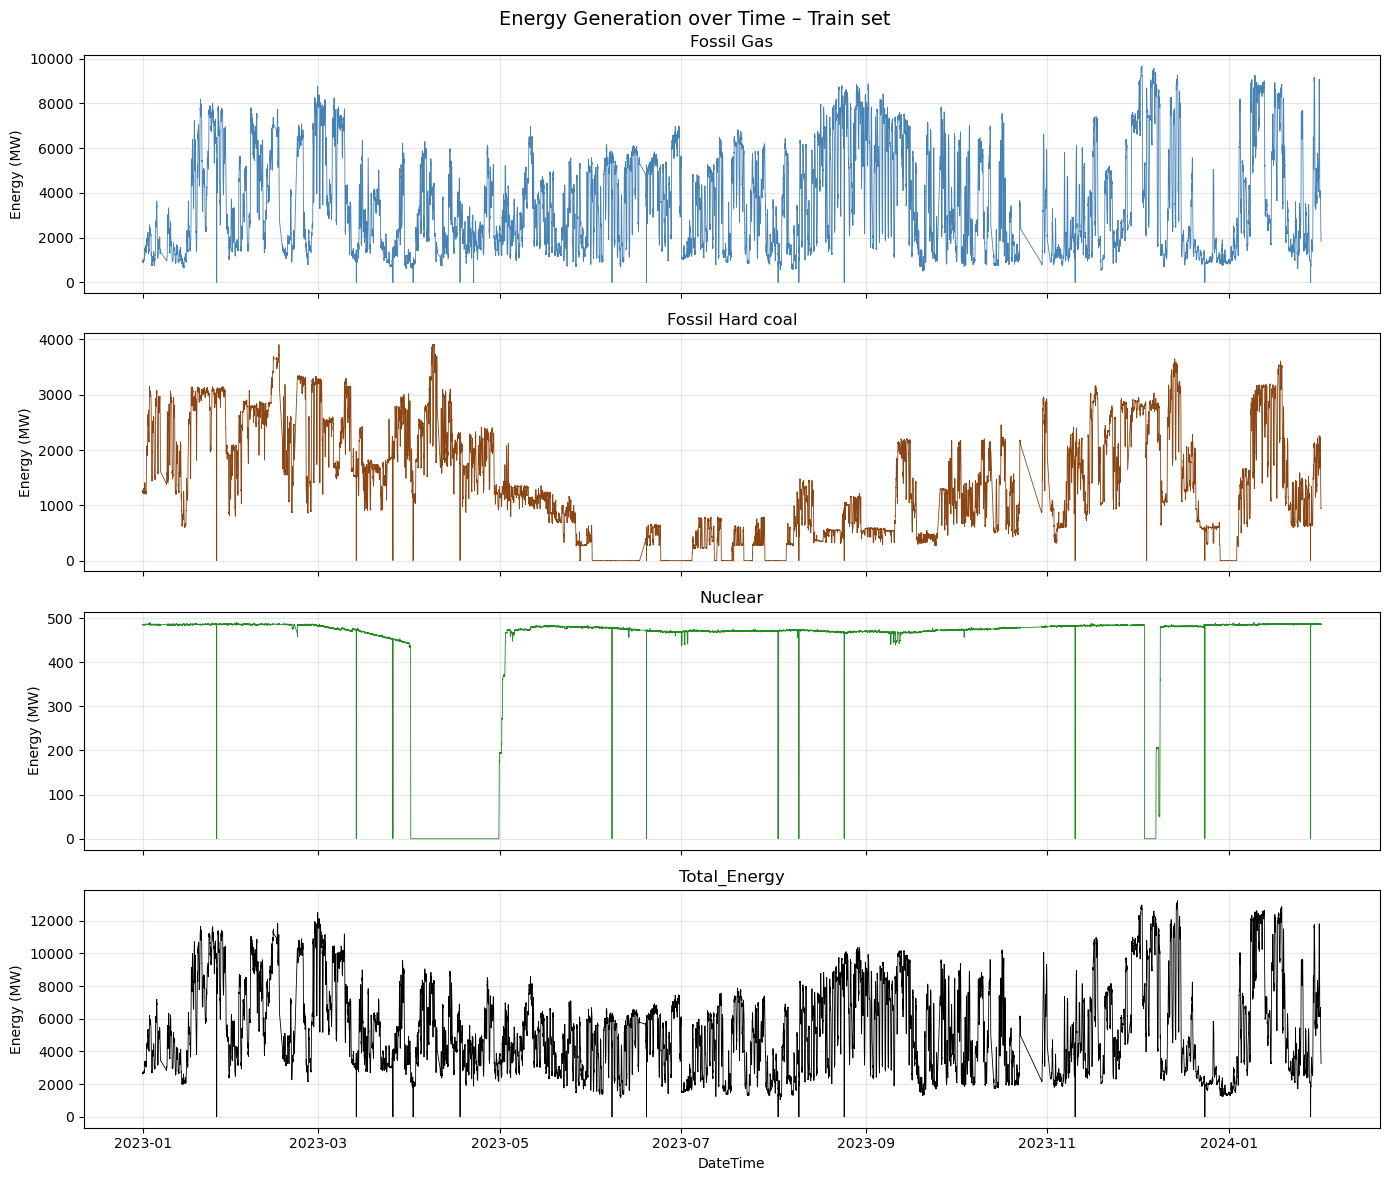

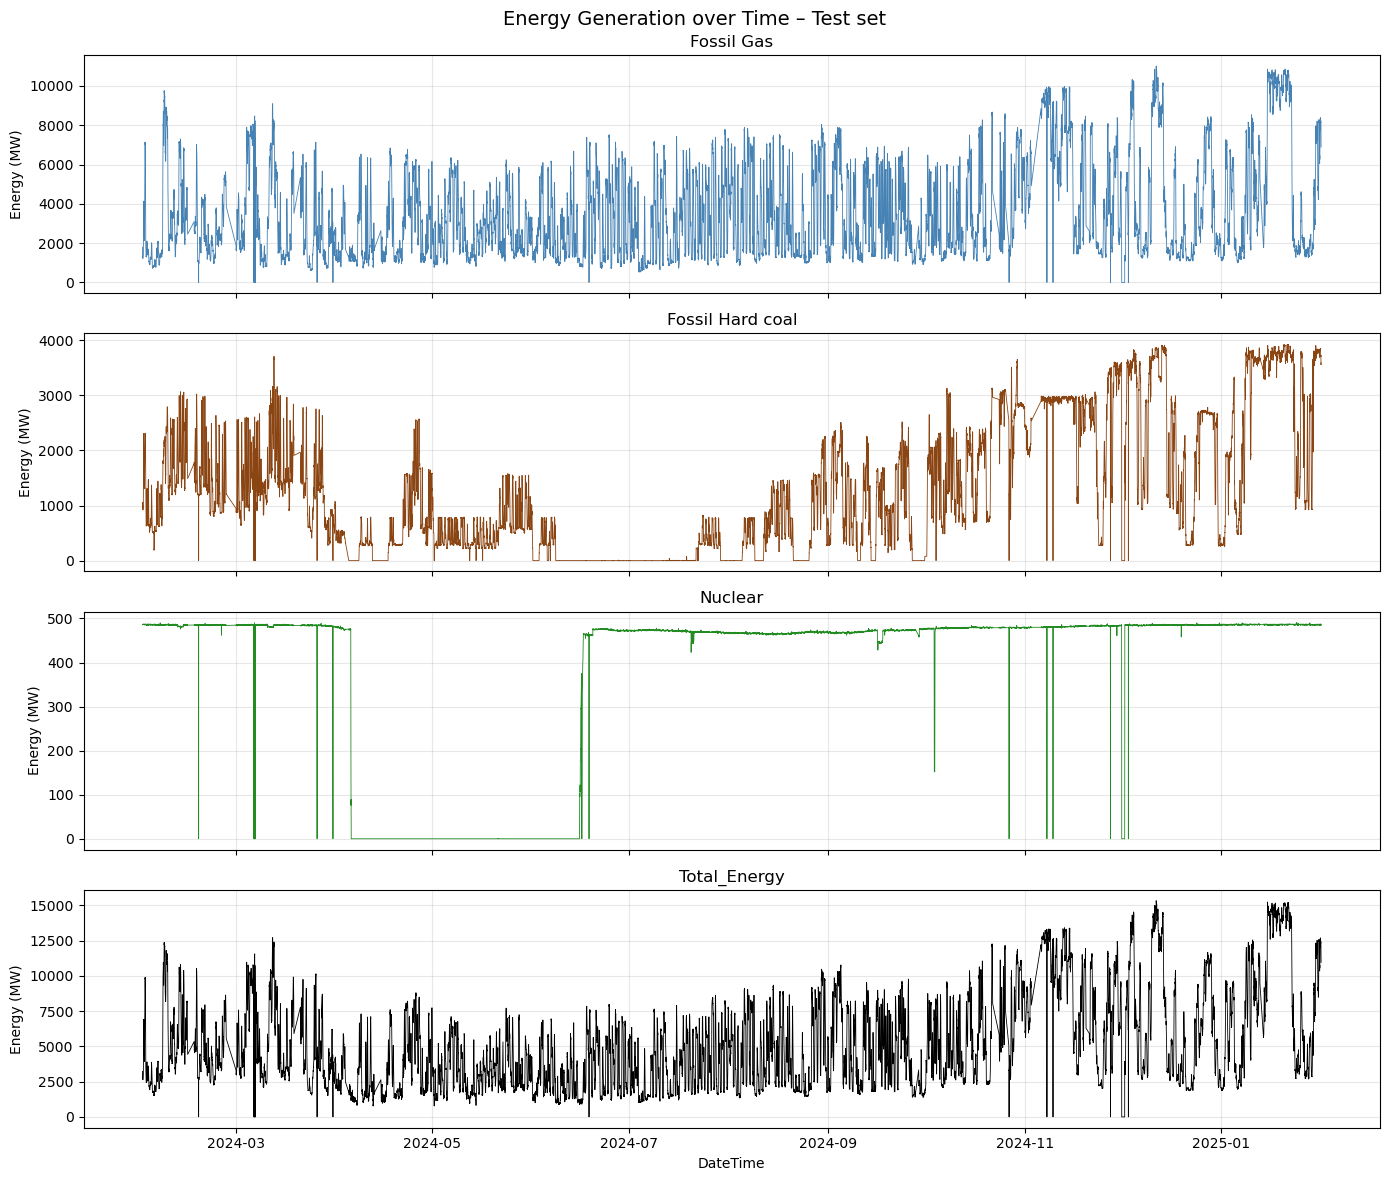

In [1901]:
for label, dataset in [("Train", df), ("Test", test)]:
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

    cols   = ["Fossil Gas", "Fossil Hard coal", "Nuclear", "Total_Energy"]
    colors = ["steelblue", "saddlebrown", "forestgreen", "black"]

    for ax, col, color in zip(axes, cols, colors):
        ax.plot(dataset["DateTime"], dataset[col], color=color, linewidth=0.6)
        ax.set_title(col)
        ax.set_ylabel("Energy (MW)")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("DateTime")
    fig.suptitle(f"Energy Generation over Time – {label} set", fontsize=14)
    plt.tight_layout()
    plt.show()

In [1902]:
#Remove timestamps where total energy is zero, as these represent periods with no generation and are not useful for modeling.
df   = df[df["Total_Energy"] > 0].reset_index(drop=True)
test = test[test["Total_Energy"] > 0].reset_index(drop=True)

print(f"Train rows after removing zero-energy timestamps: {len(df)}")
print(f"Test rows after removing zero-energy timestamps:  {len(test)}")


Train rows after removing zero-energy timestamps: 36163
Test rows after removing zero-energy timestamps:  33174


In [1903]:
#Identify missing timeframes 
for label, dataset in [("Train", df), ("Test", test)]:
    sorted_times = dataset["DateTime"].sort_values().reset_index(drop=True)
    
    gaps = []
    for i in range(1, len(sorted_times)):
        diff = (sorted_times.iloc[i] - sorted_times.iloc[i - 1]).total_seconds() / 60
        if diff > 15:
            gaps.append((sorted_times.iloc[i - 1], sorted_times.iloc[i], diff / 60))

    print(f"=== {label} set ===")
    if not gaps:
        print("  No missing timeframes found.\n")
    else:
        print(f"  {len(gaps)} gap(s) found:")
        for start, end, duration in gaps:
            print(f"    {start}  -->  {end}  ({duration:.2f}h missing)")
        print()


=== Train set ===
  25 gap(s) found:
    2023-01-07 00:00:00  -->  2023-01-09 00:15:00  (48.25h missing)
    2023-01-25 20:45:00  -->  2023-01-25 21:15:00  (0.50h missing)
    2023-01-25 21:30:00  -->  2023-01-25 22:00:00  (0.50h missing)
    2023-02-14 00:00:00  -->  2023-02-15 00:15:00  (24.25h missing)
    2023-02-16 00:00:00  -->  2023-02-17 00:15:00  (24.25h missing)
    2023-02-21 00:00:00  -->  2023-02-22 00:15:00  (24.25h missing)
    2023-03-13 19:15:00  -->  2023-03-13 19:45:00  (0.50h missing)
    2023-03-26 01:45:00  -->  2023-03-26 03:15:00  (1.50h missing)
    2023-04-01 21:30:00  -->  2023-04-01 22:00:00  (0.50h missing)
    2023-04-10 00:00:00  -->  2023-04-11 00:15:00  (24.25h missing)
    2023-04-17 15:00:00  -->  2023-04-17 16:45:00  (1.75h missing)
    2023-06-07 17:15:00  -->  2023-06-07 17:45:00  (0.50h missing)
    2023-06-17 00:00:00  -->  2023-06-19 00:15:00  (48.25h missing)
    2023-06-19 07:30:00  -->  2023-06-19 08:00:00  (0.50h missing)
    2023-08-02 12:1

In [1904]:
def fill_gaps(dataset, label):
    numeric_cols = ["Fossil Gas", "Fossil Hard coal", "Nuclear", "Total_Energy"]
    dataset = dataset.sort_values("DateTime").reset_index(drop=True)

    full_range = pd.date_range(start=dataset["DateTime"].iloc[0],
                               end=dataset["DateTime"].iloc[-1], freq="15min")
    missing_times = full_range.difference(dataset["DateTime"])

    if len(missing_times) == 0:
        print(f"=== {label} set: no missing timestamps ===\n")
        return dataset

    blocks, block = [], [missing_times[0]]
    for t in missing_times[1:]:
        if (t - block[-1]).total_seconds() == 900:
            block.append(t)
        else:
            blocks.append(block)
            block = [t]
    blocks.append(block)

    new_rows = []
    summary_rows = []

    for block in blocks:
        before = dataset[dataset["DateTime"] < block[0]].iloc[-1]
        after  = dataset[dataset["DateTime"] > block[-1]].iloc[0]

        n = len(block)
        for i, t in enumerate(block, start=1):
            frac = i / (n + 1)
            row = {"DateTime": t}
            for c in numeric_cols:
                row[c] = round(before[c] + frac * (after[c] - before[c]), 2)
            new_rows.append(row)

        # Build summary row
        gap_label = f"{block[0].strftime('%Y-%m-%d %H:%M')}  ({n} step{'s' if n > 1 else ''})"
        summary = {"Gap": gap_label}
        for c in numeric_cols:
            diff = after[c] - before[c]
            sign = "+" if diff > 0 else ""
            pct  = (diff / before[c] * 100) if before[c] != 0 else float("nan")
            summary[(c, "abs diff")] = f"{sign}{round(diff, 2)}"
            summary[(c, "% diff")]   = f"{sign}{round(pct, 1)}%"
        summary_rows.append(summary)

    # Build MultiIndex summary table
    df_summary = pd.DataFrame(summary_rows).set_index("Gap")
    df_summary.columns = pd.MultiIndex.from_tuples(
        [(c, m) for c in numeric_cols for m in ["abs diff", "% diff"]]
    )
    print(f"=== {label} set: {len(blocks)} gap(s) ===")
    display(df_summary)
    print()

    filled = pd.concat([dataset, pd.DataFrame(new_rows)], ignore_index=True)
    filled = filled.sort_values("DateTime").reset_index(drop=True)
    print(f"Rows before: {len(dataset)}, rows after: {len(filled)}\n")
    return filled

df   = fill_gaps(df,   "Train")
test = fill_gaps(test, "Test")



=== Train set: 25 gap(s) ===


Fossil Gas          Fossil Hard coal           \
                                abs diff   % diff         abs diff   % diff   
Gap                                                                           
2023-01-07 00:15  (192 steps)     -378.0   -27.7%           -226.0   -14.0%   
2023-01-25 21:00  (1 step)        +284.0    +4.9%            -51.0    -1.7%   
2023-01-25 21:45  (1 step)        -614.0   -10.0%            +14.0    +0.5%   
2023-02-14 00:15  (96 steps)      -248.0    -3.5%            -35.0    -1.0%   
2023-02-16 00:15  (96 steps)     -1242.0   -45.0%           -963.0   -30.9%   
2023-02-21 00:15  (96 steps)     +4980.0  +321.5%          +1496.0   +82.1%   
2023-03-13 19:30  (1 step)        -124.0    -9.2%             +8.0    +0.4%   
2023-03-26 02:00  (5 steps)        -40.0    -2.8%            -35.0    -1.6%   
2023-04-01 21:45  (1 step)         +11.0    +1.6%           -263.0   -18.8%   
2023-04-10 00:15  (96 steps)      -173.0   -13.2%           -994.0   -35.9%   
2023-04-17 15:15  (6 steps)       +259.0   +11.2%           +189.0   +10.6%   
2023-06-07 17:30  (1 step)        +446.0   +11.7%              0.0     nan%   
2023-06-17 00:15  (192 steps)     -479.0    -9.0%           +363.0    +nan%   
2023-06-19 07:45  (1 step)        +368.0    +8.2%            -18.0    -5.5%   
2023-08-02 12:30  (3 steps)       -271.0   -23.3%              0.0     0.0%   
2023-08-09 12:45  (1 step)        -309.0   -21.5%             +2.0    +0.3%   
2023-08-24 18:15  (1 step)        +131.0    +1.7%             +3.0    +0.3%   
2023-09-25 00:15  (96 steps)     +4603.0  +443.9%           +859.0  +214.2%   
2023-10-13 00:15  (96 steps)     -1461.0   -56.8%          -1448.0   -73.1%   
2023-10-23 00:15  (672 steps)    -1524.0   -63.6%          -1216.0   -57.9%   
2023-11-01 00:15  (96 steps)      -978.0   -51.0%           -962.0   -50.5%   
2023-11-10 08:30  (1 step)         -17.0    -0.8%            +60.0    +3.3%   
2023-11-28 00:15  (96 steps)      +581.0   +24.9%           +962.0   +58.6%   
2023-12-23 21:45  (5 steps)        -62.0    -7.0%             +2.0    +0.3%   
2024-01-28 11:30  (1 step)         -82.0    -8.6%             +2.0    +0.3%   

                               Nuclear        Total_Energy           
                              abs diff % diff     abs diff   % diff  
Gap                                                                  
2023-01-07 00:15  (192 steps)      0.0   0.0%       -604.0   -17.4%  
2023-01-25 21:00  (1 step)         0.0   0.0%       +233.0    +2.5%  
2023-01-25 21:45  (1 step)        -1.0  -0.2%       -601.0    -6.2%  
2023-02-14 00:15  (96 steps)       0.0   0.0%       -283.0    -2.5%  
2023-02-16 00:15  (96 steps)      -1.0  -0.2%      -2206.0   -34.7%  
2023-02-21 00:15  (96 steps)     -20.0  -4.1%      +6456.0  +167.4%  
2023-03-13 19:30  (1 step)        -1.0  -0.2%       -117.0    -3.1%  
2023-03-26 02:00  (5 steps)       +1.0  +0.2%        -74.0    -1.8%  
2023-04-01 21:45  (1 step)         0.0   nan%       -252.0   -12.2%  
2023-04-10 00:15  (96 steps)       0.0   nan%      -1167.0   -28.6%  
2023-04-17 15:15  (6 steps)        0.0   nan%       +448.0   +11.0%  
2023-06-07 17:30  (1 step)         0.0   0.0%       +446.0   +10.4%  
2023-06-17 00:15  (192 steps)     -1.0  -0.2%       -117.0    -2.0%  
2023-06-19 07:45  (1 step)         0.0   0.0%       +350.0    +6.6%  
2023-08-02 12:30  (3 steps)        0.0   0.0%       -271.0   -16.6%  
2023-08-09 12:45  (1 step)         0.0   0.0%       -307.0   -12.0%  
2023-08-24 18:15  (1 step)         0.0   0.0%       +134.0    +1.5%  
2023-09-25 00:15  (96 steps)       0.0   0.0%      +5462.0  +285.8%  
2023-10-13 00:15  (96 steps)       0.0   0.0%      -2909.0   -57.9%  
2023-10-23 00:15  (672 steps)     +2.0  +0.4%      -2738.0   -55.0%  
2023-11-01 00:15  (96 steps)      +1.0  +0.2%      -1939.0   -45.1%  
2023-11-10 08:30  (1 step)        -1.0  -0.2%        +42.0    +0.9%  
2023-11-28 00:15  (96 steps)       0.0   0.0%      +1543.0   +34.6%


Rows before: 36163, rows after: 38016

=== Test set: 29 gap(s) ===


Fossil Gas          Fossil Hard coal           \
                                abs diff   % diff         abs diff   % diff   
Gap                                                                           
2024-02-15 00:15  (192 steps)     +641.0   +26.1%           +280.0   +18.8%   
2024-02-18 09:45  (1 step)         +12.0    +1.1%              0.0     0.0%   
2024-02-27 00:15  (288 steps)    -1953.0   -50.7%           -261.0   -21.6%   
2024-03-06 13:00  (3 steps)       -245.0    -4.0%            +16.0    +1.4%   
2024-03-06 17:00  (2 steps)       +227.0    +3.0%           +522.0   +28.2%   
2024-03-06 17:45  (2 steps)       +289.0    +3.7%           +155.0    +6.5%   
2024-03-06 18:30  (2 steps)       +254.0    +3.1%            +42.0    +1.7%   
2024-03-06 19:15  (2 steps)        +23.0    +0.3%            +37.0    +1.4%   
2024-03-06 20:00  (6 steps)       -249.0    -2.9%           -572.0   -21.9%   
2024-03-06 22:00  (1 step)        -831.0   -10.2%           -332.0   -17.5%   
2024-03-06 23:00  (5 steps)      -1684.0   -23.4%            -88.0    -5.8%   
2024-03-19 00:15  (192 steps)    +1821.0   +51.8%            +58.0    +3.0%   
2024-03-26 03:15  (9 steps)       +278.0   +14.6%           +193.0   +17.2%   
2024-03-31 02:15  (4 steps)       -239.0    -8.4%             +4.0    +0.5%   
2024-04-04 00:15  (96 steps)      -392.0   -23.3%           -328.0  -100.0%   
2024-04-13 00:15  (192 steps)     +919.0   +53.4%              0.0     nan%   
2024-06-18 15:30  (1 step)        +250.0    +6.1%              0.0     nan%   
2024-09-28 00:15  (96 steps)     +1704.0  +145.9%              0.0     nan%   
2024-10-22 00:15  (192 steps)    -2143.0   -46.7%            -39.0    -1.3%   
2024-10-26 00:15  (96 steps)     -1871.0   -47.8%           -544.0   -17.6%   
2024-10-27 02:15  (1 step)         -38.0    -2.3%           -392.0   -24.4%   
2024-11-03 00:15  (288 steps)    +3930.0   +79.9%           +359.0   +14.2%   
2024-11-07 20:30  (1 step)         -65.0    -0.7%            +24.0    +0.8%   
2024-11-09 17:15  (3 steps)        -45.0    -0.5%             -7.0    -0.2%   
2024-11-20 00:15  (96 steps)      -256.0    -8.9%           -110.0    -3.8%   
2024-11-27 13:30  (2 steps)       -386.0   -10.4%             +2.0    +0.1%   
2024-12-01 01:15  (92 steps)      -512.0   -27.1%          -1430.0   -40.6%   
2024-12-03 03:30  (1 step)         -50.0    -1.9%            +93.0    +2.9%   
2025-01-13 00:15  (96 steps)     -3205.0   -60.5%           -198.0    -5.4%   

                               Nuclear        Total_Energy           
                              abs diff % diff     abs diff   % diff  
Gap                                                                  
2024-02-15 00:15  (192 steps)      0.0   0.0%       +921.0   +20.8%  
2024-02-18 09:45  (1 step)         0.0   0.0%        +12.0    +0.4%  
2024-02-27 00:15  (288 steps)     +1.0  +0.2%      -2213.0   -39.9%  
2024-03-06 13:00  (3 steps)        0.0   0.0%       -229.0    -2.9%  
2024-03-06 17:00  (2 steps)       -1.0  -0.2%       +748.0    +7.5%  
2024-03-06 17:45  (2 steps)       +6.0  +1.2%       +450.0    +4.2%  
2024-03-06 18:30  (2 steps)       -5.0  -1.0%       +291.0    +2.6%  
2024-03-06 19:15  (2 steps)       +1.0  +0.2%        +61.0    +0.5%  
2024-03-06 20:00  (6 steps)       -1.0  -0.2%       -822.0    -7.1%  
2024-03-06 22:00  (1 step)        +1.0  +0.2%      -1162.0   -11.0%  
2024-03-06 23:00  (5 steps)       +1.0  +0.2%      -1771.0   -19.2%  
2024-03-19 00:15  (192 steps)      0.0   0.0%      +1879.0   +31.8%  
2024-03-26 03:15  (9 steps)        0.0   0.0%       +471.0   +13.4%  
2024-03-31 02:15  (4 steps)       +1.0  +0.2%       -234.0    -5.6%  
2024-04-04 00:15  (96 steps)      +1.0  +0.2%       -719.0   -28.9%  
2024-04-13 00:15  (192 steps)      0.0   nan%       +919.0   +53.4%  
2024-06-18 15:30  (1 step)        -1.0  -0.2%       +249.0    +5.5%  
2024-09-28 00:15  (96 steps)     -14.0  -2.9%      +1690.0  +102.9%  
2024-10-22 00:15  (192 steps)  


Rows before: 33174, rows after: 35136



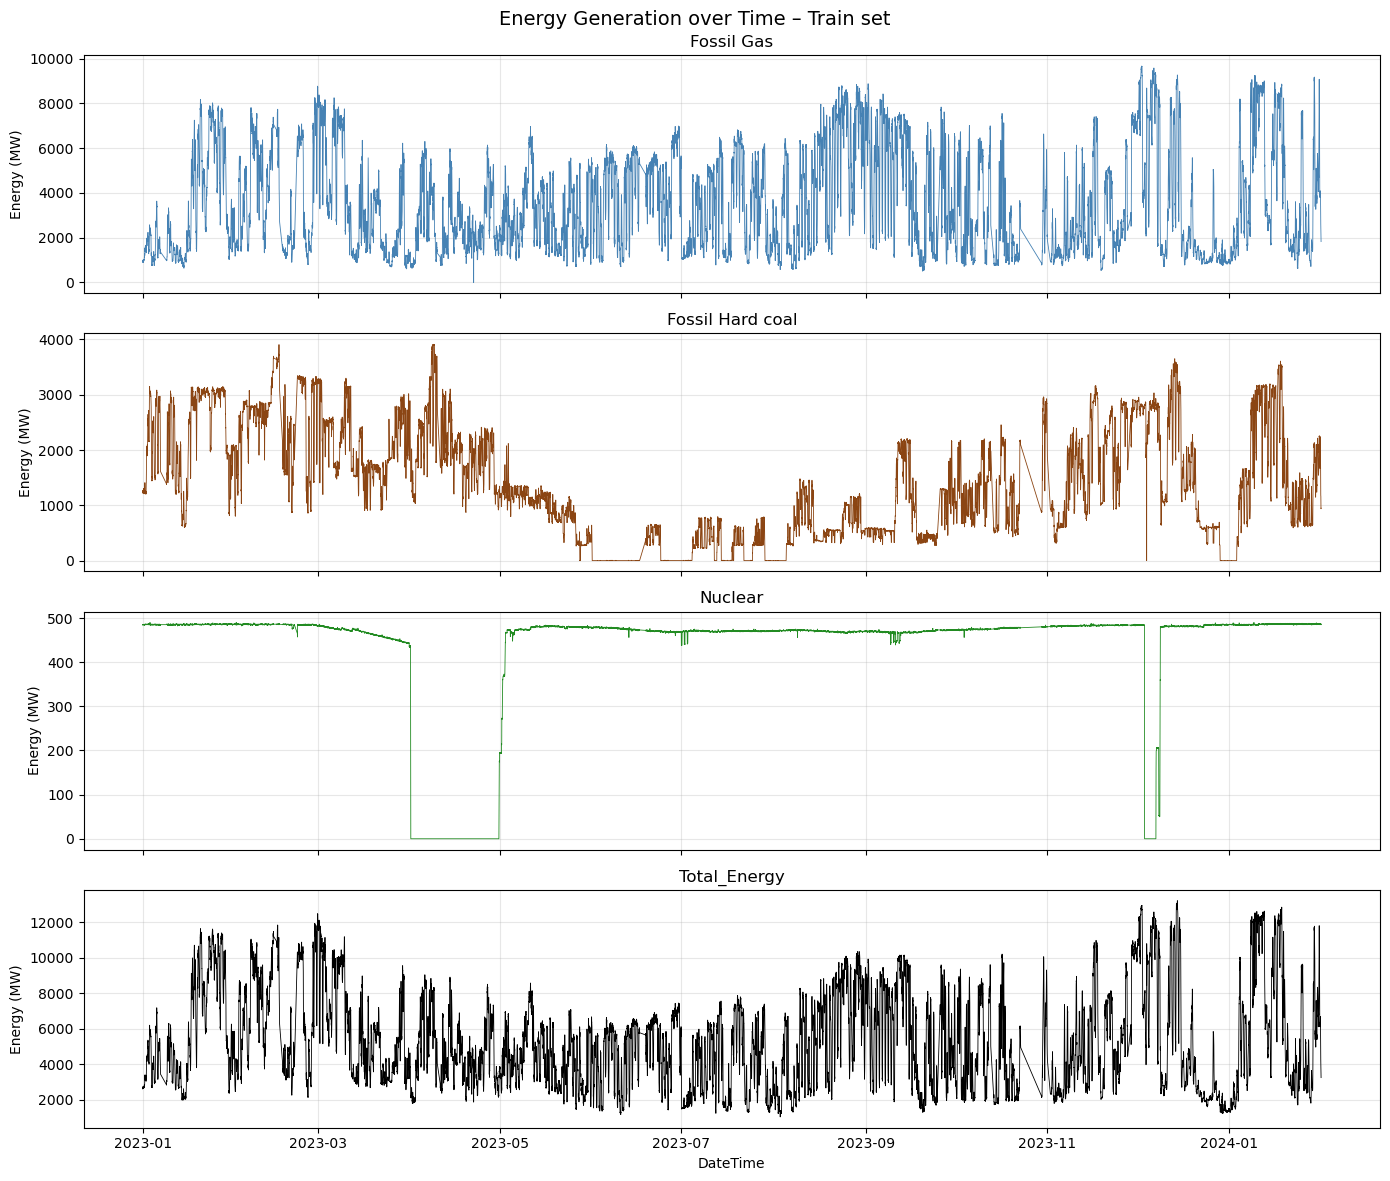

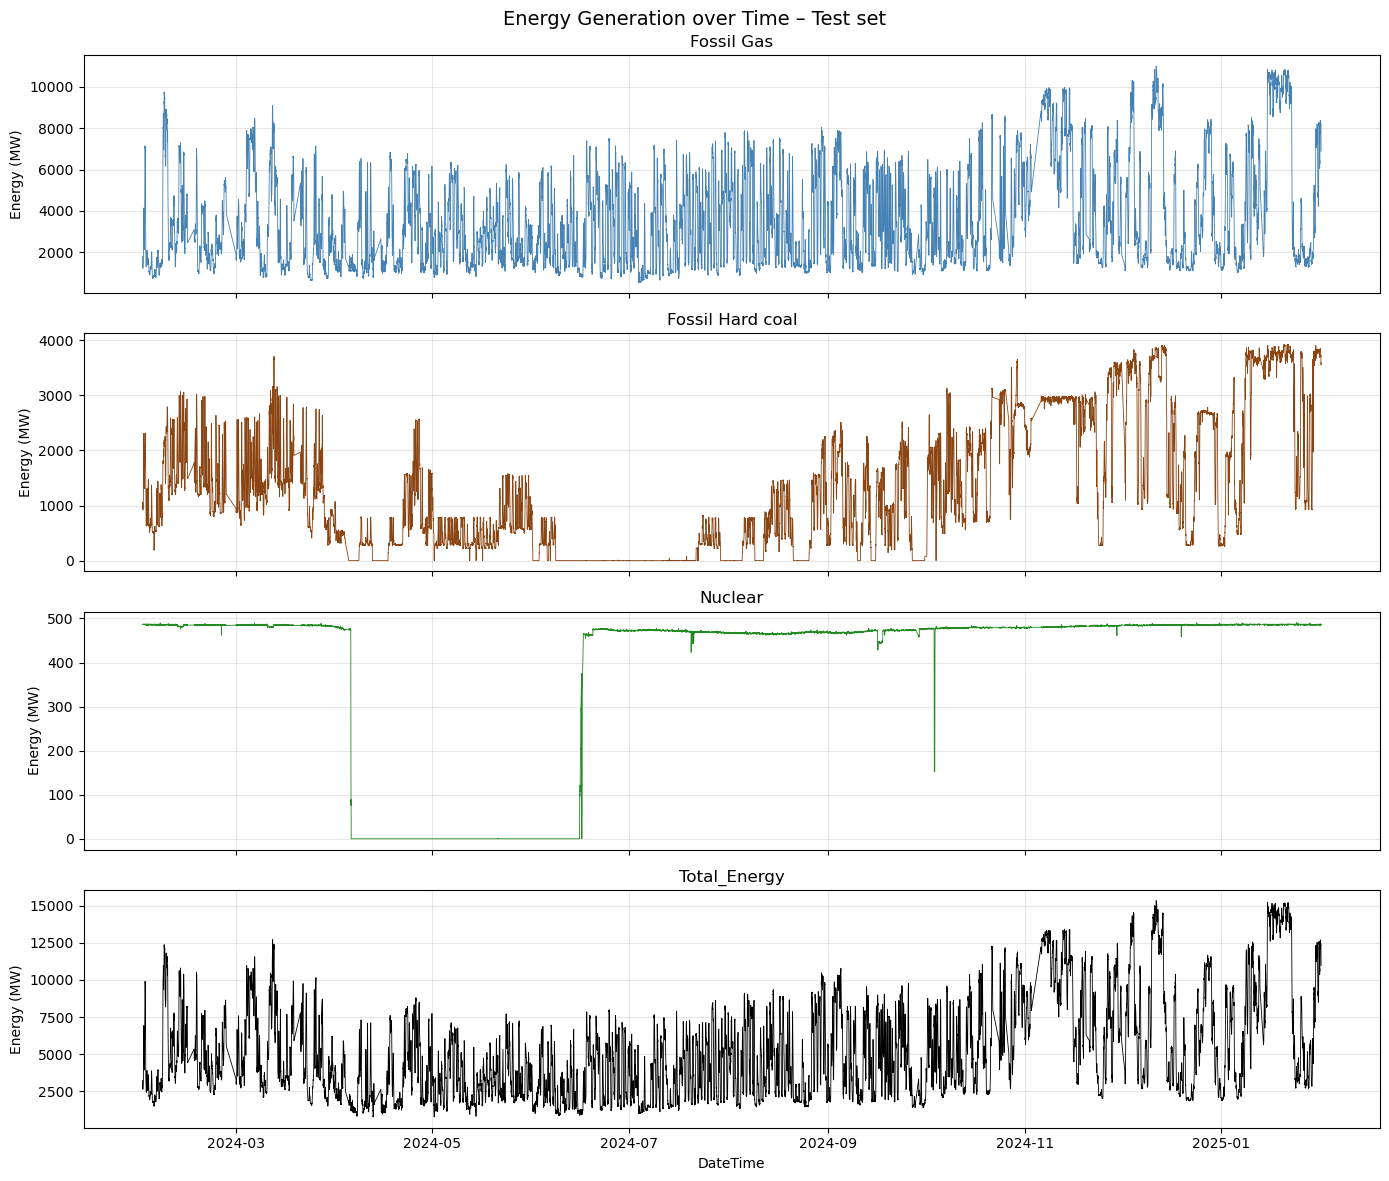

In [1905]:
for label, dataset in [("Train", df), ("Test", test)]:
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

    cols   = ["Fossil Gas", "Fossil Hard coal", "Nuclear", "Total_Energy"]
    colors = ["steelblue", "saddlebrown", "forestgreen", "black"]

    for ax, col, color in zip(axes, cols, colors):
        ax.plot(dataset["DateTime"], dataset[col], color=color, linewidth=0.6)
        ax.set_title(col)
        ax.set_ylabel("Energy (MW)")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("DateTime")
    fig.suptitle(f"Energy Generation over Time – {label} set", fontsize=14)
    plt.tight_layout()
    plt.show()

In [1906]:

def find_outliers_IQR(df):

   q1=df.quantile(0.25)

   q3=df.quantile(0.75)

   IQR=q3-q1

   outliers = df[((df<(q1-1.5*IQR)) | (df>(q3+1.5*IQR)))]

   return outliers
outliers = find_outliers_IQR(df.select_dtypes(include=[np.number]))
print ("Number of outliers in each numeric column:\n", outliers.count())
print ("Max outlier value: "+ str(outliers.max()))

Number of outliers in each numeric column:
 Wind Offshore          0
Waste               7380
Nuclear             4098
Solar               4361
Other                  4
Wind Onshore           0
Fossil Hard coal       0
Fossil Gas             0
Total_Energy          30
dtype: int64
Max outlier value: Wind Offshore           NaN
Waste                  89.0
Nuclear               448.0
Solar                 252.0
Other               11638.0
Wind Onshore            NaN
Fossil Hard coal        NaN
Fossil Gas              NaN
Total_Energy        13228.0
dtype: float64


In [1907]:
# Handle outliers
#willen we ze droppen of cappen? want alleen bij other is heel hoog maar dat isl ogisch. 

### Step: Remove Duplicates

**Why:** Duplicate rows can make some observations count more than they should. In time series data, this can confuse the model because it looks like certain moments happened more often than they actually did. This can affect the statistics of the data. By removing duplicates, it is made sure that every observation is counted only once and the data reflects reality more accurately.
**Result:** The expected result is a dataset where each observation is unique

In [1908]:
# Check for duplicates
print(f"Number of double rows: {df.duplicated().sum()}")

Number of double rows: 0


In [1909]:
# Remove duplicates
#no duplicates to remove

## 2.3 Data Reduction

### Step: Feature Selection

**Why:** Feature selection is choosing only the most relevant variables from the dataset and removing the ones that are not useful for the research. This is important, because not every variable contributes to the goal of the research, and some features may even add noise. If we keep too many irrelevant features, the model becomes more complex and harder to train, which can reduce performance.

**Result:** The expected result is a smaller dataset which consist of meaningful variables only

In [1910]:
# Feature selection analysis




In [1911]:
# Select features


### Step: Dimensionality Reduction (if applicable)

**Why:** [Explain why dimensionality reduction is necessary]

Idk of dit nodig is? ik denk het persoonlijk van niet. 

**Result:** [Describe the result]

In [1912]:
# Dimensionality reduction



## 2.4 Data Transformation

### Step: Normalization/Standardization

**Why:** 
Our energy sources have very different scales (e.g., Fossil Gas reaches 10,000+ MW while Solar might only reach 200 MW). Without scaling, the model would mistakenly think Fossil Gas is "more important" just because the numbers are larger. By scaling everything between 0 and 1, we ensure that:

1. Every feature contributes equally to the model.
2. The neural network can identify patterns more easily using small, consistent numbers.

**Result:** We used the Min-Max Scaler to transform all numerical columns into a range of 0 to 1. The training data is now perfectly scaled, and the test data has been adjusted accordingly.

In [1962]:
# Scale/normalize features
#from sklearn.preprocessing import MinMaxScaler

test = test.copy()

# 1. Initialiseer de scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# 2. Selecteer je numerieke kolommen (zonder DateTime)
# Zorg dat je target (wat je wilt voorspellen) hier ook bij zit!
numeric_cols = df.select_dtypes(include=['number']).columns


# 3. Fit op train, transformeer beide
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
test[numeric_cols] = scaler.fit_transform(test[numeric_cols])


#4. controle? 
print("Statistieken Train set:")
print(df[numeric_cols].describe().loc[['min', 'max']])

# Bekijk de statistieken van de test data
print("\nStatistieken Test set:")
print(test[numeric_cols].describe().loc[['min', 'max']])

Statistieken Train set:
     Wind Offshore  Waste  Nuclear  Solar  Other  Wind Onshore  \
min            0.0    0.0      0.0    0.0    0.0           0.0   
max            1.0    1.0      1.0    1.0    1.0           1.0   

     Fossil Hard coal  Fossil Gas  Total_Energy  
min               0.0         0.0           0.0  
max               1.0         1.0           1.0  

Statistieken Test set:
     Wind Offshore  Waste  Nuclear  Solar  Other  Wind Onshore  \
min            0.0    0.0      0.0    0.0    0.0           0.0   
max            1.0    1.0      1.0    1.0    1.0           1.0   

     Fossil Hard coal  Fossil Gas  Total_Energy  
min               0.0         0.0           0.0  
max               1.0         1.0           1.0  


### Step: Encoding Categorical Variables (if applicable)

**Why:** [Explain why encoding is necessary]
there is no categorical variables in this dataset. 

**Result:** [Describe the encoding method used]

In [1963]:
# Encode categorical variables
#there is no

### Step: Feature Engineering

**Why:** [Explain why creating new features is beneficial]

**Result:** [Describe new features created]

In [1964]:
# Create new features


---

# 3. Organize Time-Dependent Data (4 pts)

## Time Series Organization Strategy

**Strategy Description:**

[Describe your strategy for organizing time-dependent data. Consider:
- How do you create sequences?
- What is your sequence length (window size)?
- Do you use overlapping windows?
- What is your prediction horizon?
- How do you handle the temporal ordering?]

**Motivation:**

[Explain why you chose this particular strategy]
36,000 observations over 13 months, the data has a 15-minute frequency

**Visual Representation:**

[Include a figure showing your windowing strategy]

<!-- Example: ![Windowing Strategy](images/windowing_strategy.png) -->

In [1965]:
# Sort data by time
#already done in the beginning 
df = df.sort_values(by='DateTime').reset_index(drop=True)
print(df['DateTime'].head())

0   2023-01-01 00:00:00
1   2023-01-01 00:15:00
2   2023-01-01 00:30:00
3   2023-01-01 00:45:00
4   2023-01-01 01:00:00
Name: DateTime, dtype: datetime64[us]


In [1966]:
# Create sequences/windows for time series
def create_sequences(df, sequence_length):
    """
    Converts a 2D dataframe into 3D arrays for RNN input.
    """
    # Extract only the numerical features (ignore DateTime for the math)
    data = df.select_dtypes(include=[np.number]).values
    
    X, y = [], []
    
    # Slide the window across the data
    for i in range(len(data) - sequence_length):
        # The past 'sequence_length' steps
        X.append(data[i : i + sequence_length])
        # The very next step after the window (predicting all features)
        y.append(data[i + sequence_length])
        
    return np.array(X), np.array(y)

# Set window size to 24 hours (96 steps of 15-minutes)
SEQ_LENGTH = 96

# Create sequences for the train set (df) and test set (test)
X_data, y_data = create_sequences(df, SEQ_LENGTH)
X_test, y_test = create_sequences(test, SEQ_LENGTH)

print(f"Original df shape: {df.shape}")
print(f"X_data (Features) shape: {X_data.shape} -> (Samples, Timesteps, Features)")
print(f"y_data (Targets) shape: {y_data.shape} -> (Samples, Features)")
print(f"Original test shape: {test.shape}")
print(f"X_test (Features) shape: {X_test.shape} -> (Samples, Timesteps, Features)")
print(f"y_test (Targets) shape: {y_test.shape} -> (Samples, Features)")

Original df shape: (38016, 10)
X_data (Features) shape: (37920, 96, 9) -> (Samples, Timesteps, Features)
y_data (Targets) shape: (37920, 9) -> (Samples, Features)
Original test shape: (35136, 10)
X_test (Features) shape: (35040, 96, 9) -> (Samples, Timesteps, Features)
y_test (Targets) shape: (35040, 9) -> (Samples, Features)


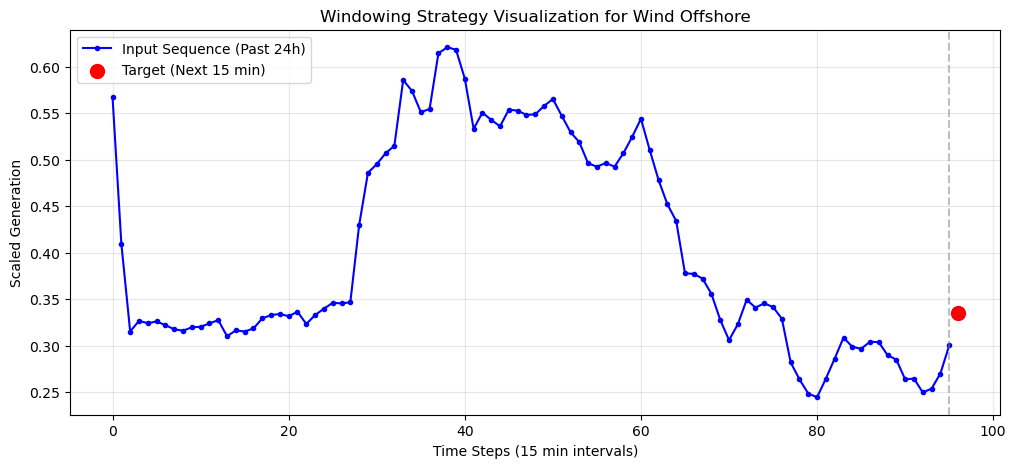

In [1967]:
# Visualize the windowing strategy
# Let's visualize the very first sequence and its target for a specific feature
feature_idx = 0 # 'Fossil Gas' (assuming it's the first numerical column)
feature_name = df.select_dtypes(include=[np.number]).columns[feature_idx]

plt.figure(figsize=(12, 5))

# Plot the 96 steps of the input sequence (X)
plt.plot(range(SEQ_LENGTH), X_data[0, :, feature_idx], label='Input Sequence (Past 24h)', color='blue', marker='.')

# Plot the 1 step of the target (y)
plt.scatter(SEQ_LENGTH, y_data[0, feature_idx], color='red', s=100, label='Target (Next 15 min)', zorder=5)

plt.axvline(x=SEQ_LENGTH-1, color='gray', linestyle='--', alpha=0.5)
plt.title(f'Windowing Strategy Visualization for {feature_name}')
plt.xlabel('Time Steps (15 min intervals)')
plt.ylabel('Scaled Generation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

# 4. Prepare Data for Model Selection and Evaluation (4 pts)

## Experimental Setup

**Data Splitting Strategy:**

[Describe how you split the data:
- Training set: X% (time period: ...)
- Validation set: Y% (time period: ...)
- Test set: Z% (time period: ...)]

**Validation Strategy:**

[Specify the validation approach:
- Hold-out validation
- Time series cross-validation
- Walk-forward validation
- Other]

**Rationale:**

[Explain why this setup is appropriate for time series data]

**Visual Summary:**

[Include a figure clearly showing the train/validation/test split]

<!-- Example: ![Experimental Setup](images/train_val_test_split.png) -->

In [1968]:
# Split data into train, validation, and test sets


In [1969]:
# Create visualization of the split


In [1970]:
# Display split information


---

# 5. Build RNN Prediction Model (5 pts)

## Model Architecture Selection

**Chosen Architecture:** [LSTM / GRU / Simple RNN / Bidirectional LSTM / etc.]

**Motivation:**

[Explain why you chose this particular RNN architecture for your problem]

## Hyperparameter Selection

**Selected/Optimized Hyperparameters:**

- Number of layers:
- Hidden units per layer:
- Dropout rate:
- Learning rate:
- Batch size:
- Number of epochs:
- Optimizer:
- Loss function:
- Other:

**Motivation:**

[Explain the reasoning behind your hyperparameter choices or the optimization strategy used]

In [1971]:
# Define model architecture


In [1972]:
# Display model summary


In [1973]:
# Compile model


In [1974]:
# Train model


---

# 6. Training and Validation Loss Analysis (2 pts)

## Loss Visualization

In [1975]:
# Plot training and validation losses


## Loss Analysis

**Observed Trends:**

[Describe the trends you observe in the training and validation loss curves]

**Underfitting/Overfitting Assessment:**

[Analyze whether the model shows signs of:
- Underfitting (high training and validation loss)
- Overfitting (low training loss but high validation loss)
- Good fit (both losses decrease and converge)]

**Implications:**

[Discuss what these trends mean for model performance and potential improvements]

---

# 7. Model Evaluation (3 pts)

## Evaluation Metrics

**Selected Metrics:**

[List the metrics you will use, e.g.:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)
- R² Score
- Others]

**Rationale:**

[Explain why these metrics are appropriate for your problem]

In [1976]:
# Make predictions on test set


In [1977]:
# Calculate evaluation metrics


In [1978]:
# Display evaluation results


## Results Discussion

**Performance Summary:**

[Summarize the numerical results from your evaluation metrics]

**Interpretation:**

[Discuss what these results mean:
- How well does the model perform?
- Are the results acceptable for the problem domain?
- What are the strengths and weaknesses?
- How does it compare to baseline expectations?]

---

# 8. Predictions vs Ground Truth Visualization (2 pts)

In [1979]:
# Create plot comparing predictions and ground truth


## Visual Analysis

[Provide observations about the plot:
- How well do predictions match ground truth?
- Are there systematic errors?
- Where does the model perform well/poorly?]

---

# Conclusion

## Summary

[Summarize the key findings and model performance]

## Future Improvements

[Discuss potential improvements:
- Alternative architectures
- Hyperparameter tuning
- Additional features
- Ensemble methods
- Other preprocessing techniques]

---

# References

[List any references or resources used]